In [1]:
# Mount Drive and Prepare Data
from google.colab import drive
import zipfile
import os
import shutil

# Mount Drive
drive.mount('/content/drive')

# Setup Folder
if os.path.exists('/content/food_data'):
    shutil.rmtree('/content/food_data')
os.makedirs('/content/food_data', exist_ok=True)

# Unzip Images (This takes 1-2 mins)
zip_path = '/content/drive/MyDrive/Colab Notebooks/data.zip'
print("Unzipping images...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/food_data')

# Copy CSVs
shutil.copy('/content/drive/MyDrive/Colab Notebooks/train.csv.csv', '/content/food_data/train.csv.csv')
shutil.copy('/content/drive/MyDrive/Colab Notebooks/test.csv', '/content/food_data/test.csv')
print("✅ Files ready.")


Mounted at /content/drive
Unzipping images...
✅ Files ready.


In [2]:
# Imports and Data Loading
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import os

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Class Implementation
class FoodDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, is_test=False):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        if not is_test:
            self.categories = sorted(self.df['label_name'].unique())
            self.label_map = {name: i for i, name in enumerate(self.categories)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        full_csv_path = str(self.df.loc[idx, 'image_path'])
        path_parts = full_csv_path.replace('\\', '/').split('/')
        actual_path = os.path.join(self.root_dir, 'images', path_parts[-2], path_parts[-1])

        image = Image.open(actual_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, self.df.loc[idx, 'original_index']

        label = self.label_map[self.df.loc[idx, 'label_name']]
        return image, torch.tensor(label)

# Advanced Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize Full Dataset
data_root = '/content/food_data/data/food-101'
full_train_dataset = FoodDataset('/content/food_data/train.csv.csv', data_root, transform=train_transform)

# 70/30 Data Split
# Splitting 7,500 images into 5,250 (Train) and 2,250 (Validation)
train_size = int(0.7 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for Optuna and Training
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

# Final Validation Check
print("--- Validation Check ---")
print(f"Total Dataset: {len(full_train_dataset)} images")
print(f"Training set: {len(train_subset)} images (70%)")
print(f"Validation set: {len(val_subset)} images (30%)")
print(f"Device: {device}")

--- Validation Check ---
Total Dataset: 7500 images
Training set: 5250 images (70%)
Validation set: 2250 images (30%)
Device: cuda


In [3]:
# 5-Layer "Super Deep CNN" Architecture
class SuperDeepAssignmentCNN(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super(SuperDeepAssignmentCNN, self).__init__()

        # Block 1: Input 224x224 -> Output 112x112
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 112x112 -> 56x56
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: 56x56 -> 28x28
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Block 4: 28x28 -> 14x14
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # NEW Block 5: 14x14 -> 7x7
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)

        # Fully Connected Layers
        # 512 channels * 7 * 7 spatial dimension = 25088
        self.fc1 = nn.Linear(512 * 7 * 7, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, 10) # 10 Food Classes

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x)))) # 5th Layer

        x = x.view(-1, 512 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
# Grid Search with 3-Fold Cross-Validation
from sklearn.model_selection import KFold

param_grid = {'lr': [5e-4, 1e-4], 'dropout': [0.4, 0.5]}
kf = KFold(n_splits=3, shuffle=True, random_state=42)
results_table = []

print("Starting Systematic Grid Search...")
for lr in param_grid['lr']:
    for do in param_grid['dropout']:
        fold_accs = []
        for fold, (train_idx, val_idx) in enumerate(kf.split(full_train_dataset)):
            # Create loaders for this fold
            train_sub = torch.utils.data.Subset(full_train_dataset, train_idx)
            val_sub = torch.utils.data.Subset(full_train_dataset, val_idx)
            loader_train = DataLoader(train_sub, batch_size=32, shuffle=True)
            loader_val = DataLoader(val_sub, batch_size=32, shuffle=False)

            # Init Model
            model = SuperDeepAssignmentCNN(dropout_rate=do).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = nn.CrossEntropyLoss()

            # Short Training to find best params
            for epoch in range(15):
                model.train()
                for imgs, lbls in loader_train:
                    imgs, lbls = imgs.to(device), lbls.to(device)
                    optimizer.zero_grad()
                    loss = criterion(model(imgs), lbls)
                    loss.backward()
                    optimizer.step()

            # Val Accuracy
            model.eval()
            correct = 0
            with torch.no_grad():
                for imgs, lbls in loader_val:
                    imgs, lbls = imgs.to(device), lbls.to(device)
                    correct += (model(imgs).argmax(1) == lbls).sum().item()
            fold_accs.append(correct / len(val_sub))

        avg_acc = np.mean(fold_accs)
        results_table.append({'lr': lr, 'dropout': do, 'avg_acc': avg_acc})
        print(f"LR: {lr}, DO: {do} -> Avg Acc: {avg_acc:.4f}")

summary_df = pd.DataFrame(results_table)
print("\n--- Summary Table for Report ---")
print(summary_df)

Starting Systematic Grid Search...
LR: 0.0005, DO: 0.4 -> Avg Acc: 0.4440
LR: 0.0005, DO: 0.5 -> Avg Acc: 0.4347
LR: 0.0001, DO: 0.4 -> Avg Acc: 0.5621
LR: 0.0001, DO: 0.5 -> Avg Acc: 0.5281

--- Summary Table for Report ---
       lr  dropout   avg_acc
0  0.0005      0.4  0.444000
1  0.0005      0.5  0.434667
2  0.0001      0.4  0.562133
3  0.0001      0.5  0.528133


Starting Training: 40 Epochs with Loss Tracking on cuda...
Epoch [1/40] - Train Loss: 2.0469 - Val Loss: 1.7936
Epoch [2/40] - Train Loss: 1.7457 - Val Loss: 1.6940
Epoch [3/40] - Train Loss: 1.6400 - Val Loss: 1.5088
Epoch [4/40] - Train Loss: 1.5344 - Val Loss: 1.4522
Epoch [5/40] - Train Loss: 1.4531 - Val Loss: 1.4181
Epoch [6/40] - Train Loss: 1.3963 - Val Loss: 1.4958
Epoch [7/40] - Train Loss: 1.3424 - Val Loss: 1.4394
Epoch [8/40] - Train Loss: 1.2983 - Val Loss: 1.3542
Epoch [9/40] - Train Loss: 1.2478 - Val Loss: 1.3214
Epoch [10/40] - Train Loss: 1.2254 - Val Loss: 1.3028
Epoch [11/40] - Train Loss: 1.1154 - Val Loss: 1.1659
Epoch [12/40] - Train Loss: 1.0914 - Val Loss: 1.2212
Epoch [13/40] - Train Loss: 1.0587 - Val Loss: 1.1652
Epoch [14/40] - Train Loss: 1.0433 - Val Loss: 1.1407
Epoch [15/40] - Train Loss: 1.0176 - Val Loss: 1.1288
Epoch [16/40] - Train Loss: 1.0130 - Val Loss: 1.1395
Epoch [17/40] - Train Loss: 1.0041 - Val Loss: 1.1142
Epoch [18/40] - Train Loss: 0.95

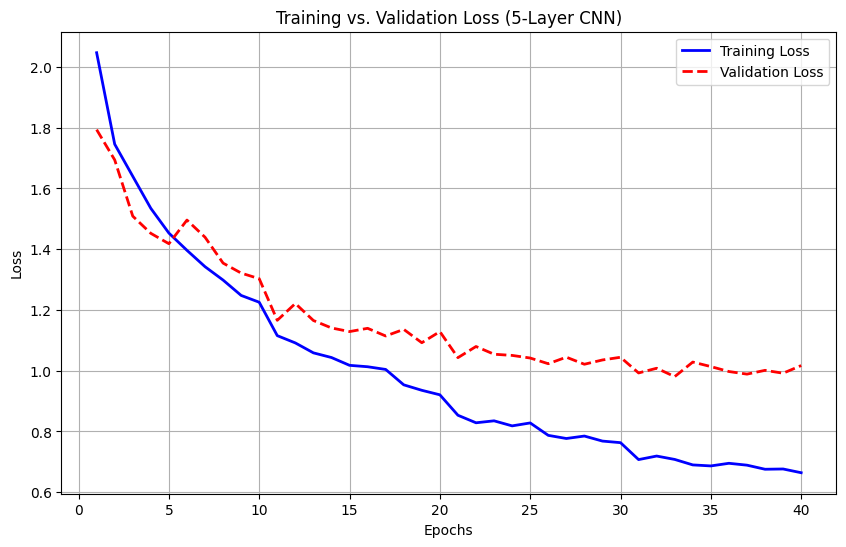

Generating Kaggle predictions for 2,500 images...
Done! File and Plot generated.


In [4]:
# Final Training and Kaggle Submission with Loss Plotting

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms

# Define Test Transform
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Configuration & Model Init
best_lr = 0.0001
best_do = 0.4
final_model = SuperDeepAssignmentCNN(dropout_rate=best_do).to(device)

# Setup Optimizer, Loss, and Scheduler
optimizer = optim.Adam(final_model.parameters(), lr=best_lr, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# History Trackers for the Report Plot
train_loss_history = []
val_loss_history = []

# Loaders (Using the 70/30 subsets for the plot)
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

print(f"Starting Training: 40 Epochs with Loss Tracking on {device}...")

# Training Loop
for epoch in range(1, 41):
    final_model.train()
    running_train_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = final_model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    # Calculate Average Training Loss
    avg_train_loss = running_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation Loss Calculation (For the plot)
    final_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = final_model(imgs)
            v_loss = criterion(outputs, lbls)
            running_val_loss += v_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    scheduler.step()
    print(f"Epoch [{epoch}/40] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

    if epoch % 10 == 0:
        torch.save(final_model.state_dict(), f"model_5layer_epoch_{epoch}.pth")

# GENERATE THE PLOT
plt.figure(figsize=(10, 6))
plt.plot(range(1, 41), train_loss_history, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, 41), val_loss_history, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Training vs. Validation Loss (5-Layer CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')
plt.show()

# Final Inference on Kaggle Test Set
print(f"Generating Kaggle predictions for 2,500 images...")
test_dataset = FoodDataset('/content/food_data/test.csv', data_root, transform=test_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
results = []
inv_label_map = {v: k for k, v in full_train_dataset.label_map.items()}

with torch.no_grad():
    for imgs, indices in test_loader:
        imgs = imgs.to(device)
        preds = final_model(imgs).argmax(1)
        for idx, p in zip(indices, preds):
            results.append({"original_index": int(idx), "label_name": inv_label_map[p.item()]})

pd.DataFrame(results).to_csv("deep_5layer_final_attempt.csv", index=False)
print("Done! File and Plot generated.")

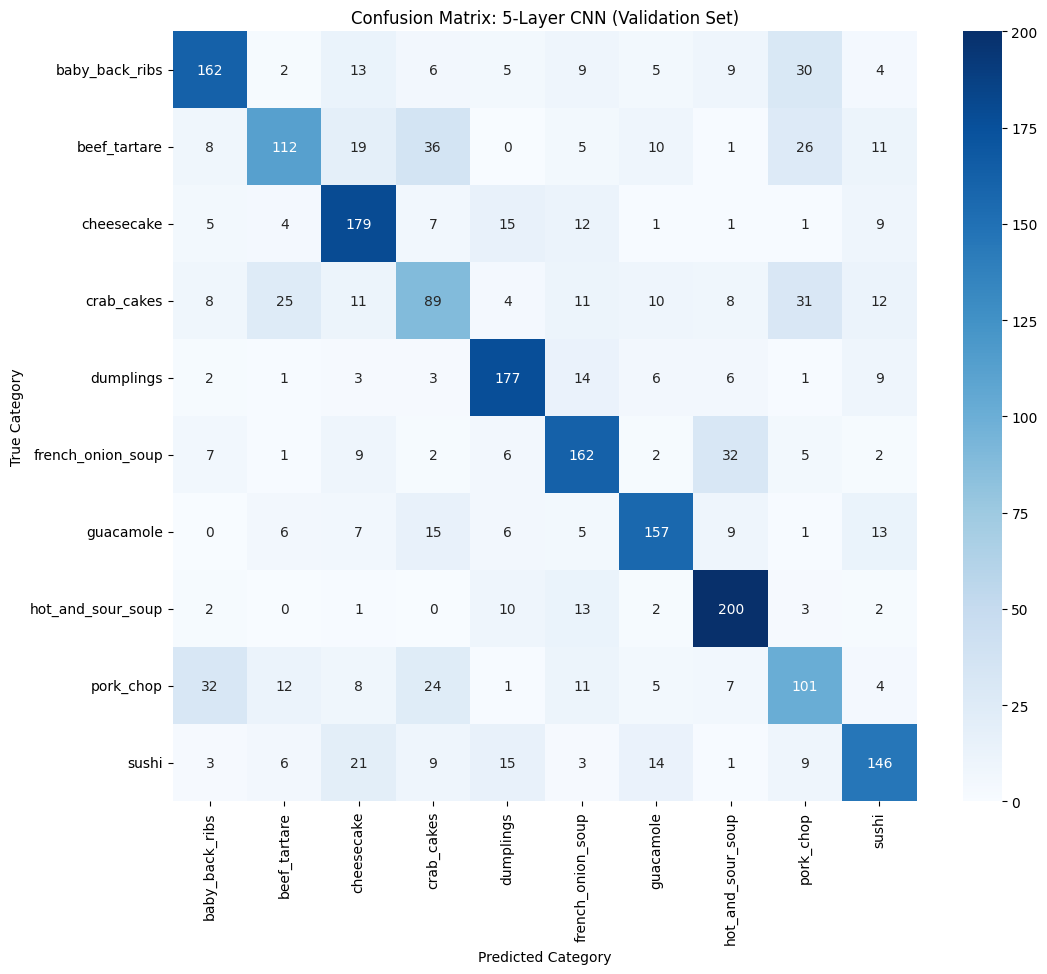

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get Predictions on the 30% Validation Set
final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in val_loader: # Uses the 2,250 images from 70/30
        imgs = imgs.to(device)
        outputs = final_model(imgs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

# Generate Matrix
categories = full_train_dataset.categories
cm = confusion_matrix(all_labels, all_preds)

# Plotting Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix: 5-Layer CNN (Validation Set)')
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.savefig('Confusion Matrix: 5-Layer CNN (Validation Set).png')
plt.show()